In [1]:
import json
import time

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.patches import Rectangle
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("data/final.csv")

In [3]:
df.head()

,Bwd Pkt Len Std,Bwd Pkts/s,Dst Port,Flow Duration,Flow IAT Std,Fwd IAT Std,Init Fwd Win Byts,Pkt Len Std,Tot Bwd Pkts,TotLen Bwd Pkts,Label
0,655.432936,49.510203,443,141385,19069.116850,23965.32327,8192,474.712955,7,3773.0,Benign
1,0.000000,3558.718861,49684,281,174.655375,0.00000,123,21.939310,1,0.0,Benign
2,636.314186,53.605123,443,279824,24379.448340,36167.74032,8192,566.234209,15,10527.0,Benign
3,0.000000,0.000000,443,132,0.000000,0.00000,256,0.000000,0,0.0,Benign
4,611.180489,47.442485,443,274016,26311.627030,37996.56546,8192,497.254764,13,6141.0,Benign


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11916138 entries, 0 to 11916137
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Bwd Pkt Len Std    float64
 1   Bwd Pkts/s         float64
 2   Dst Port           int64  
 3   Flow Duration      int64  
 4   Flow IAT Std       float64
 5   Fwd IAT Std        float64
 6   Init Fwd Win Byts  int64  
 7   Pkt Len Std        float64
 8   Tot Bwd Pkts       int64  
 9   TotLen Bwd Pkts    float64
 10  Label              str    
dtypes: float64(6), int64(4), str(1)
memory usage: 1000.0 MB


In [5]:
X = df.drop(['Label'], axis=1)
y = df['Label']

In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [7]:
y_encoded

array([ 0,  0,  0, ..., 12,  0, 12], shape=(11916138,))

In [8]:
for real_name, encoded_name in zip(le.classes_, le.transform(le.classes_)):
    print(f"{encoded_name}: {real_name}")

0: Benign
1: Bot
2: Brute Force -Web
3: Brute Force -XSS
4: DDOS attack-HOIC
5: DDOS attack-LOIC-UDP
6: DDoS attacks-LOIC-HTTP
7: DoS attacks-GoldenEye
8: DoS attacks-Hulk
9: DoS attacks-SlowHTTPTest
10: DoS attacks-Slowloris
11: FTP-BruteForce
12: Infilteration
13: SQL Injection
14: SSH-Bruteforce


In [9]:
%%time

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42
)

eval_set = [(X_val, y_val)]

CPU times: user 4.63 s, sys: 187 ms, total: 4.82 s
Wall time: 4.89 s


In [10]:
counts = pd.Series(y_train).value_counts()
classes = counts.index

beta = 0.9999
eff_num = 1.0 - np.power(beta, counts.values)
weights = (1.0 - beta) / eff_num
weights = weights / weights.mean()  # normalize around 1.0

# Cap the max weight ratio — prevents any single tiny class from
# dominating the loss and destabilizing majority-class precision
def cap_ratio(w, max_ratio=100):
    w = np.minimum(w, w.min() * max_ratio)
    return w / w.mean()

weights = cap_ratio(weights, max_ratio=100)

class_weight_map = dict(zip(classes, weights))
sample_weight_train = pd.Series(y_train).map(class_weight_map).values
sample_weight_val   = pd.Series(y_val).map(class_weight_map).values

In [11]:
params = {
    #'device': 'cuda',
    'objective': 'multi:softprob',
    'eval_metric': 'aucpr',
    
    'max_depth': 5,
    'min_child_weight': 5,
    
    'learning_rate': 0.1,
    'n_estimators': 1000,
    'early_stopping_rounds': 10,
    'tree_method': 'hist',
    
    'subsample': 0.8,
    'colsample_bytree': 0.8,

    #'enable_categorical': True
}

In [12]:
model = xgb.XGBClassifier(**params)

In [13]:
%%time

model.fit(
    X_train, y_train,
    sample_weight=sample_weight_train,
    eval_set=eval_set,
    sample_weight_eval_set=[sample_weight_val],
)

[0]	validation_0-aucpr:0.60288
[1]	validation_0-aucpr:0.74064
[2]	validation_0-aucpr:0.75668
[3]	validation_0-aucpr:0.76790
[4]	validation_0-aucpr:0.78930
[5]	validation_0-aucpr:0.80620
[6]	validation_0-aucpr:0.80637
[7]	validation_0-aucpr:0.80199
[8]	validation_0-aucpr:0.80691
[9]	validation_0-aucpr:0.80527
[10]	validation_0-aucpr:0.80699
[11]	validation_0-aucpr:0.80754
[12]	validation_0-aucpr:0.80809
[13]	validation_0-aucpr:0.80867
[14]	validation_0-aucpr:0.81254
[15]	validation_0-aucpr:0.81347
[16]	validation_0-aucpr:0.81378
[17]	validation_0-aucpr:0.81424
[18]	validation_0-aucpr:0.81518
[19]	validation_0-aucpr:0.81556
[20]	validation_0-aucpr:0.81551
[21]	validation_0-aucpr:0.81579
[22]	validation_0-aucpr:0.81614
[23]	validation_0-aucpr:0.81689
[24]	validation_0-aucpr:0.81748
[25]	validation_0-aucpr:0.81793
[26]	validation_0-aucpr:0.81789
[27]	validation_0-aucpr:0.81834
[28]	validation_0-aucpr:0.81888
[29]	validation_0-aucpr:0.82018
[30]	validation_0-aucpr:0.82056
[31]	validation_0-

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.d

In [14]:
%%time

y_preds = model.predict(X_test)

CPU times: user 1min 35s, sys: 70.4 ms, total: 1min 35s
Wall time: 13.4 s


In [15]:
# Source - https://stackoverflow.com/a/53780589
# Posted by janus235, modified by community. See post 'Timeline' for change history
# Retrieved 2026-09-12, License - CC BY-SA 4.0

report = classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_preds),
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
#df_report.to_csv("classification_report.csv", encoding="utf-8", index=True)
df_report

,precision,recall,f1-score,support
Benign,0.987037,0.999744,0.993350,2.112747e+06
Bot,0.999931,0.996739,0.998332,2.912800e+04
Brute Force -Web,0.770000,0.626016,0.690583,1.230000e+02
Brute Force -XSS,0.893617,0.893617,0.893617,4.700000e+01
DDOS attack-HOIC,0.999824,1.000000,0.999912,3.980400e+04
DDOS attack-LOIC-UDP,0.663516,0.988732,0.794118,3.550000e+02
DDoS attacks-LOIC-HTTP,0.999948,0.998103,0.999024,1.149090e+05
DoS attacks-GoldenEye,0.998210,0.997972,0.998091,8.383000e+03
DoS attacks-Hulk,1.000000,0.999897,0.999948,2.905000e+04
DoS attacks-SlowHTTPTest,0.047619,0.125000,0.068966,8.000000e+00


In [16]:
def confusionMatrixPlot(title, x_label, y_label, y_test, y_pred):
    """Plot confusion matrix for XGBoost model trained on selected features only"""
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(10, 10))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.unique(y_test)
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    plt.xticks(rotation=90)
    plt.title(
        f"{title}",
        fontsize = 16,
        fontweight="bold"
    )

    ax.set_xlabel(
        f"{x_label}",
        fontsize=12
    )
    ax.set_ylabel(
        f"{y_label}",
        fontsize=12
    )

    fig.savefig(f"images/{title}.png", bbox_inches="tight")

    plt.tight_layout()
    plt.show()

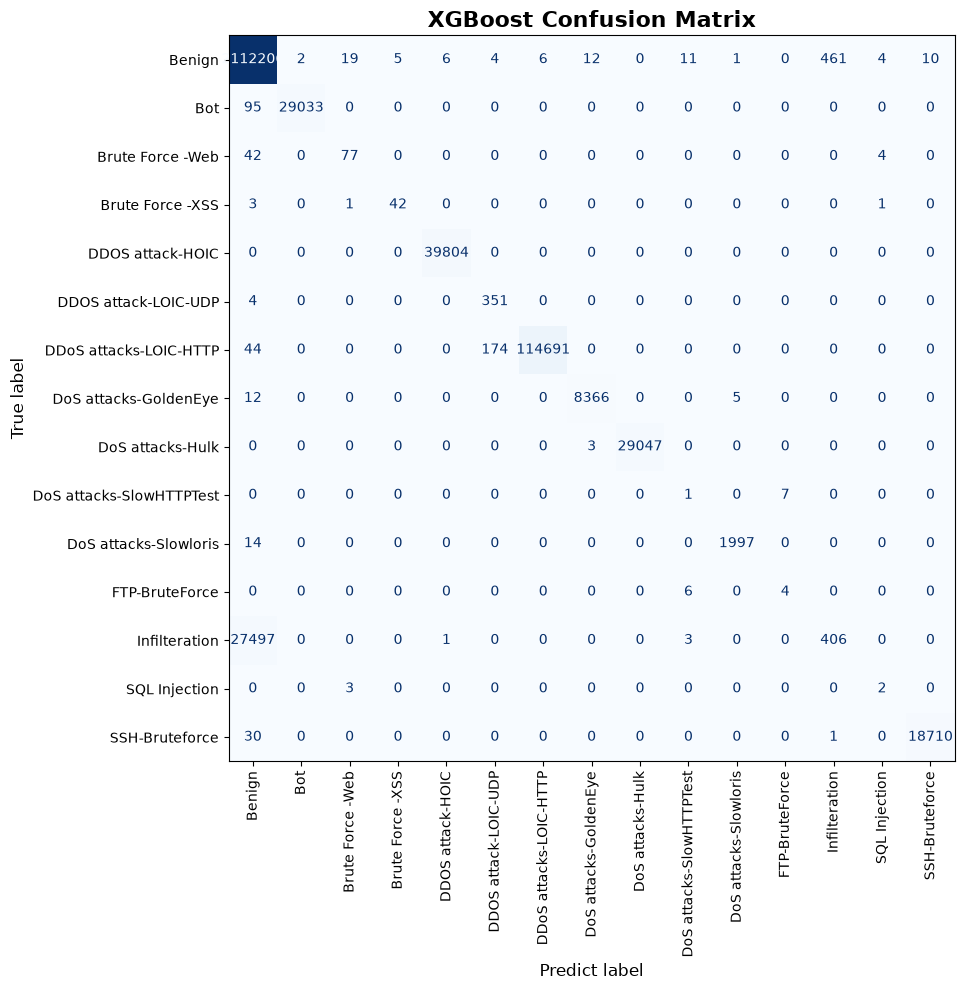

CPU times: user 10.2 s, sys: 55.8 ms, total: 10.2 s
Wall time: 10.2 s


In [17]:
%%time

confusionMatrixPlot(
    "XGBoost Confusion Matrix",
    "Predict label",
    "True label",
    le.inverse_transform(y_test),
    le.inverse_transform(y_preds)
)